Next, we make the runoff conditions.

In [61]:
# import modules for computation and plotting
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec
import netCDF4 as nc4
from scipy.ndimage import gaussian_filter
#import cmocean.cm as cm

# import pertinent tools from eccoseas
from eccoseas.ecco import pickup
from eccoseas.ecco import grid
from eccoseas.ecco import io
from eccoseas.downscale import horizontal
from eccoseas.downscale import vertical
from eccoseas.downscale import interpolation_grid as ecco_interp
from eccoseas.toolbox import reprojection

## Constructing the Initial Conditions
For this model, we will use runoff from ECCO

### Step 1: Download the ECCO Files
To begin, ensure that all of the necessary pickup and grid files are obtained for this configuration. These are listed on the Overview page for this model. 

These files are stored in the following directory:

In [13]:
data_folder = '/Users/mhwood/Documents/Research/Projects/Chukchi_Sea/Data'

### Step 2: Read in the Regional Model Grid and Mask
Since the model grid has already been generated for this model (see note in the Model Grid notebook), we will read it in from the nc file:

In [14]:
# define the parameters that will be used in the data file
ds = nc4.Dataset(os.path.join(data_folder,'Chukchi_Sea_grid.nc'))
XC = ds.variables['XC'][:, :]
YC = ds.variables['YC'][:, :]
bathy = -1*ds.variables['Depth'][:,:]
AngleCS = ds.variables['AngleCS'][:,:]
AngleSN = ds.variables['AngleSN'][:,:]
hFacC = ds.variables['HFacC'][:, :, :]
hFacW = ds.variables['HFacW'][:, :, :]
hFacS = ds.variables['HFacS'][:, :, :]
delR = ds.variables['drF'][:]
ds.close()

# remove the extra row and col from hFacS and hFacW
hFacS = hFacS[:,:-1,:]
hFacW = hFacW[:,:,:-1]

In [15]:
maskC = np.copy(hFacC)
maskC[maskC>0] = 1

maskW = np.copy(hFacW)
maskW[maskW>0] = 1

maskS = np.copy(hFacS)
maskS[maskS>0] = 1

### Step 3: Read in the pickup file and the ECCO grid
To read in the pickup, we will rely on the `pickup` module from the `eccoseas.ecco`:

In [17]:
runoff_faces = io.read_ecco_field_to_faces(os.path.join(data_folder,'Model Setup Files','runoff-2d-Fekete-1deg-mon-V4-SMOOTH.bin'),
                                        llc=270, dim=3, Nr=12)

Following the previous notebooks, we will organize the data into ECCO tiles for the interpolation. As of now, the pickup file is read into ECCO faces. The `grid` module allows for an easy conversion to tiles.

In [20]:
runoff_tiles = grid.ecco_faces_to_tiles(runoff_faces, llc=270, dim=3)

Next, we will read in the ECCO grid and convert the grid to tiles:

In [23]:
ecco_XC_faces, ecco_YC_faces, ecco_AngleCS_faces, ecco_AngleSN_faces, ecco_hFacC_faces, ecco_hFacW_faces, ecco_hFacS_faces =\
     io.read_ecco_geometry_to_faces(data_folder+'/Model Setup Files', llc=270, Nr=50)

In [25]:
ecco_XC_tiles = grid.ecco_faces_to_tiles(ecco_XC_faces, llc=270, dim=2)
ecco_YC_tiles = grid.ecco_faces_to_tiles(ecco_YC_faces, llc=270, dim=2)
ecco_AngleCS_tiles = grid.ecco_faces_to_tiles(ecco_AngleCS_faces, llc=270, dim=2)
ecco_AngleSN_tiles = grid.ecco_faces_to_tiles(ecco_AngleSN_faces, llc=270, dim=2)
ecco_hFacC_tiles = grid.ecco_faces_to_tiles(ecco_hFacC_faces, llc=270, dim=3)
ecco_hFacS_tiles = grid.ecco_faces_to_tiles(ecco_hFacS_faces, llc=270, dim=3)
ecco_hFacW_tiles = grid.ecco_faces_to_tiles(ecco_hFacW_faces, llc=270, dim=3)
ecco_RF = np.fromfile(os.path.join(data_folder+'/Model Setup Files','RF.data'), '>f4')
ecco_DRF = np.fromfile(os.path.join(data_folder+'/Model Setup Files','DRF.data'), '>f4')

In [26]:
ecco_Nr = np.size(ecco_DRF)

#### Plotting the pickup field
To get a sense for what the results should look like, let's first plot the initial conditions in the region around the model domain. First, define some metadata:

In [31]:
meta_dict = {'runoff':[0,1e-7, 'viridis', 'm/s']}

Then, plot each of the pickup fields around the model domain:

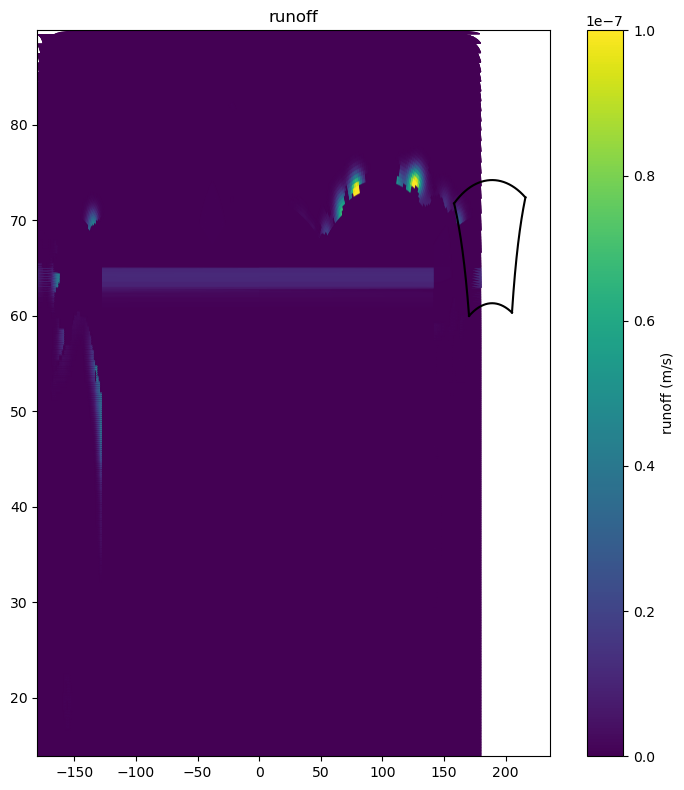

In [32]:
fig = plt.figure(figsize=(8,8))
plot_counter = 1

XC_stitched = np.vstack([np.rot90(ecco_XC_tiles[8]), np.rot90(ecco_XC_tiles[7])])
YC_stitched = np.vstack([np.rot90(ecco_YC_tiles[8]), np.rot90(ecco_YC_tiles[7])])

var_grid_stitched = np.vstack([np.rot90(runoff_tiles[8][0,:,:]), # just the surface for plotting
                              np.rot90(runoff_tiles[7][0,:,:])])

variable_name = 'runoff'

C = plt.pcolormesh(XC_stitched, YC_stitched,
                   var_grid_stitched,
                   vmin=meta_dict[variable_name][0],
                   vmax=meta_dict[variable_name][1],
                   cmap=meta_dict[variable_name][2], shading='gouraud')
plt.colorbar(C, label=variable_name+' ('+meta_dict[variable_name][3]+')',fraction=0.26)

plt.plot(XC[:,0],YC[:,0], 'k-')
plt.plot(XC[:,-1],YC[:,-1], 'k-')
plt.plot(XC[0,:],YC[0,:], 'k-')
plt.plot(XC[-1,:],YC[-1,:], 'k-')

plt.title(variable_name)

# plt.gca().set_xlim([-160,-140])
# plt.gca().set_ylim([68,73])

plot_counter+=1

plt.tight_layout()

plt.show()

We will use these fields as a sanity check below.

### Step 4: Prepare the grids for interpolation
In the previous notebook, we already discovered which tiles correspond to this grid:

In [33]:
# define the tile list
tile_list = [7,8]

We now read the grid on these tiles

In [78]:
# determine the number of points in each set
total_points = 0
for tile_number in tile_list:
    total_points += np.size(ecco_XC_tiles[tile_number])

# make empty arrays to fill in
ecco_XC_points = np.zeros((total_points, ))
ecco_YC_points = np.zeros((total_points, ))
ecco_AngleCS_points = np.zeros((total_points, ))
ecco_AngleSN_points = np.zeros((total_points, ))
ecco_maskC_points = np.zeros((ecco_Nr, total_points))
ecco_maskW_points = np.zeros((ecco_Nr, total_points))
ecco_maskS_points = np.zeros((ecco_Nr, total_points))
ecco_hFacW_points = np.zeros((ecco_Nr, total_points))
ecco_hFacS_points = np.zeros((ecco_Nr, total_points))

# loop through the tiles and fill in the XC, YC, and mask points for interpolation
points_counted = 0
for tile_number in tile_list:
    tile_N = np.size(ecco_XC_tiles[tile_number])
    
    ecco_XC_points[points_counted:points_counted+tile_N] = ecco_XC_tiles[tile_number].ravel()
    ecco_YC_points[points_counted:points_counted+tile_N] = ecco_YC_tiles[tile_number].ravel()

    ecco_AngleCS_points[points_counted:points_counted+tile_N] = ecco_AngleCS_tiles[tile_number].ravel()
    ecco_AngleSN_points[points_counted:points_counted+tile_N] = ecco_AngleSN_tiles[tile_number].ravel()
    
    for k in range(ecco_Nr):
        level_hFacC = ecco_hFacC_tiles[tile_number][k, :, :]
        if tile_number<7:
            level_hFacW = ecco_hFacW_tiles[tile_number][k, :, :]
            level_hFacS = ecco_hFacS_tiles[tile_number][k, :, :]
        else:
            level_hFacS = ecco_hFacW_tiles[tile_number][k, :, :] # these are switched due to the 
            level_hFacW = ecco_hFacS_tiles[tile_number][k, :, :] # assumptions about velocity - see note below
        ecco_hFacW_points[k, points_counted:points_counted+tile_N] = level_hFacW.ravel()
        ecco_hFacS_points[k, points_counted:points_counted+tile_N] = level_hFacS.ravel()
        level_maskC = np.copy(level_hFacC)
        level_maskC[level_maskC>0] = 1
        level_maskW = np.copy(level_hFacW)
        level_maskW[level_maskW>0] = 1
        level_maskS = np.copy(level_hFacS)
        level_maskS[level_maskS>0] = 1
        ecco_maskC_points[k, points_counted:points_counted+tile_N] = level_maskC.ravel()
        ecco_maskW_points[k, points_counted:points_counted+tile_N] = level_maskW.ravel()
        ecco_maskS_points[k, points_counted:points_counted+tile_N] = level_maskS.ravel()
    
    points_counted += tile_N

# wrap the longitude points
ecco_XC_points[ecco_XC_points<0] += 360
print(np.min(ecco_XC_points), np.max(ecco_XC_points))

# remove the points outside the immediate area
local_indices = (ecco_XC_points<250) & (ecco_XC_points>120) & (ecco_YC_points>55) & (ecco_YC_points<80)
ecco_maskC_points = ecco_maskC_points[:, local_indices]
ecco_maskW_points = ecco_maskW_points[:, local_indices]
ecco_maskS_points = ecco_maskS_points[:, local_indices]
ecco_hFacW_points = ecco_hFacW_points[:, local_indices]
ecco_hFacS_points = ecco_hFacS_points[:, local_indices]
ecco_YC_points = ecco_YC_points[local_indices]
ecco_XC_points = ecco_XC_points[local_indices]

0.011043190719376206 359.9883990673076


### Step 5: Subset and vertically interpolate the ECCO fields

Next, we'll read in the data fields and apply some modifications including the following:
- Rotate vector quantities to ordinal directions.
- Subset to the same ECCO indices as the grid subsets above
- Interpolate the quantities to the same vertical grid cells

In [79]:
# make a list to hold all of the ECCO grids
init_grids = []

print(' - Processing Runoff')

grid_tiles = runoff_tiles

# create a grid of zeros to fill in
N = np.shape(grid_tiles[7])[-1]*np.shape(grid_tiles[7])[-2]
init_grid = np.zeros((12, N*len(tile_list)))

# loop through the tiles
points_counted = 0
for tile_number in tile_list:
    for k in range(12):
        init_grid[k,points_counted:points_counted+N] = \
             grid_tiles[tile_number][k, :, :].ravel()
    points_counted += N

# remove the points with positive longitudes
init_grid = init_grid[:,local_indices]



 - Processing Runoff


### Step 6: Interpolate the Physical Fields onto the Model Grid
Next, we will interpolate the ECCO pickup fields onto the regional model domain. We will use interpolation grid we generated in the previous notebook for efficient interpolation.

Just as in the creation the interpolation grid, let's reproject the coordinates to ensure the bi-linear interpolation occurs without artefacts. We can do this with the `reprojection` model provided with **eccoseas**:

In [80]:
utm_zone_epsg = 32602
utm_coordinates = reprojection.reproject_polygon(np.column_stack([ecco_XC_points, ecco_YC_points]), 4326, utm_zone_epsg)

regional_coordinates = reprojection.reproject_polygon(np.column_stack([XC.ravel(), YC.ravel()]), 4326, utm_zone_epsg)
X = regional_coordinates[:,0].reshape(np.shape(XC))
Y = regional_coordinates[:,1].reshape(np.shape(XC))

Finally, let's use our interpolation grid to proceed with the interpolation:

In [81]:
interpolation_grid_file = os.path.join(data_folder,'Model Setup Files','Chukchi_Sea_interpolation_grid.nc')


print('  - Interpolating the runoff grid')
print('    - Reading the interpolation mask')
interpolation_grid_components = ecco_interp.read_interpolation_grid_for_variable(interpolation_grid_file, 'Theta')
interpolation_mask = interpolation_grid_components['interp_type']
source_rows = interpolation_grid_components['source_rows']
source_cols = interpolation_grid_components['source_cols']
source_levels = interpolation_grid_components['source_levels']

regional_mask = maskC[:1,:,:]
ecco_mask = ecco_maskC_points[:1,:]

interpolated_grid = np.zeros((12, np.shape(maskC)[1], np.shape(maskC)[2]))
print(np.shape(interpolated_grid))

print(np.shape(utm_coordinates), np.shape(init_grid[5:6,:]), np.shape(ecco_mask))

for k in range(12):

    print('    - Running the downscale scheme')
    int_grid = horizontal.downscale_3D_points(utm_coordinates, init_grid[k:k+1,:], ecco_mask,
                                               X, Y, regional_mask,
                                               printing=True, testing=False)
    interpolated_grid[k,:,:] = int_grid[0,:,:]

  - Interpolating the runoff grid
    - Reading the interpolation mask
(12, 720, 960)
(47920, 2) (1, 47920) (1, 47920)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Working on level 0 of 1 (354377 nonzero points found)
    - Running the downscale scheme
    Worki

Now, we will Gaussian smooth these fields

In [88]:
def create_gaussian_kernel(size, sigma):
    """
    Creates a 2D Gaussian kernel.

    Args:
        size (int): The side length of the square kernel (e.g., 10 for a 10x10 kernel).
        sigma (float): The standard deviation of the Gaussian distribution.

    Returns:
        numpy.ndarray: The 2D Gaussian kernel.
    """
    kernel_1d = np.linspace(-(size // 2), size // 2, size)
    x, y = np.meshgrid(kernel_1d, kernel_1d)
    kernel_2d = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel_2d /= np.sum(kernel_2d)  # Normalize the kernel
    return kernel_2d

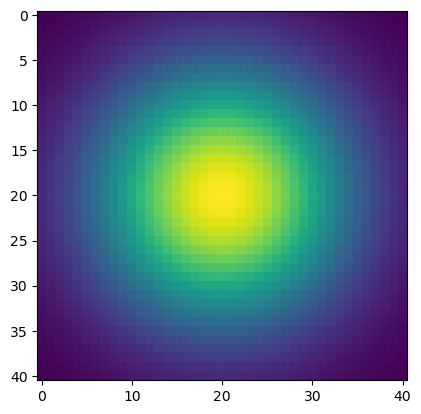

In [136]:
plt.imshow(create_gaussian_kernel(41, sigma=10))
plt.show()

In [139]:
N = 41
radius = N//2
kernel = create_gaussian_kernel(N, sigma=10)
print(np.shape(kernel))

smooth_interpolated_grid = np.zeros_like(interpolated_grid)
sigma = 10

for k in range(12):
    data = interpolated_grid[k,:,:]
    print(k)
    
    for row in range(np.shape(interpolated_grid)[1]):
        # if row%50==0:
        #     print(row)
        for col in range(np.shape(interpolated_grid)[2]):

            if maskC[0,row,col]!=0:

                # compute the subset sizes
                min_row_index = np.max([0, row-radius])
                max_row_index = np.min([np.shape(interpolated_grid)[1]-1, row+radius+1])
                min_col_index = np.max([0, col-radius])
                max_col_index = np.min([np.shape(interpolated_grid)[2]-1, col+radius+1])

                # get the subsets of the data, the mask, and the kernel
                data_subset = data[min_row_index:max_row_index, min_col_index:max_col_index]
                mask_subset = maskC[0, min_row_index:max_row_index, min_col_index:max_col_index]
                kernel_subset = kernel[
                                        (min_row_index - row + radius):(max_row_index - row + radius),
                                        (min_col_index - col + radius):(max_col_index - col + radius)]
                
                # mask the kernel
                kernel_subset = kernel_subset*mask_subset

                # normalize the kernel
                kernel_subset /= np.sum(kernel_subset)

                # smooth the point with the kernel
                smooth_interpolated_grid[k,row,col] = np.sum(data_subset*kernel_subset)

(41, 41)
0
1
2
3
4
5
6
7
8
9
10
11


In [140]:
input_dir = '/Users/mhwood/Documents/Research/Projects/Chukchi_Sea/Model/input'

In [141]:
smooth_interpolated_grid.ravel(order='C').astype('>f4').tofile(input_dir + '/runoff-2d-Fekete.bin')

### Step 7: Plotting the Initial Condition Fields
Now that the fields have been generated, we will plot them to ensure they look as expected.

First, let's read in the fields from the file we made to ensure this file was made correctly:

In [142]:
runoff_grid = np.fromfile(input_dir + '/runoff-2d-Fekete.bin', '>f4').reshape((12, 720, 960))

In [146]:
meta_dict = {'runoff':[0,1e-7, 'viridis', 'm/s']}

Then, create all of the subplots:

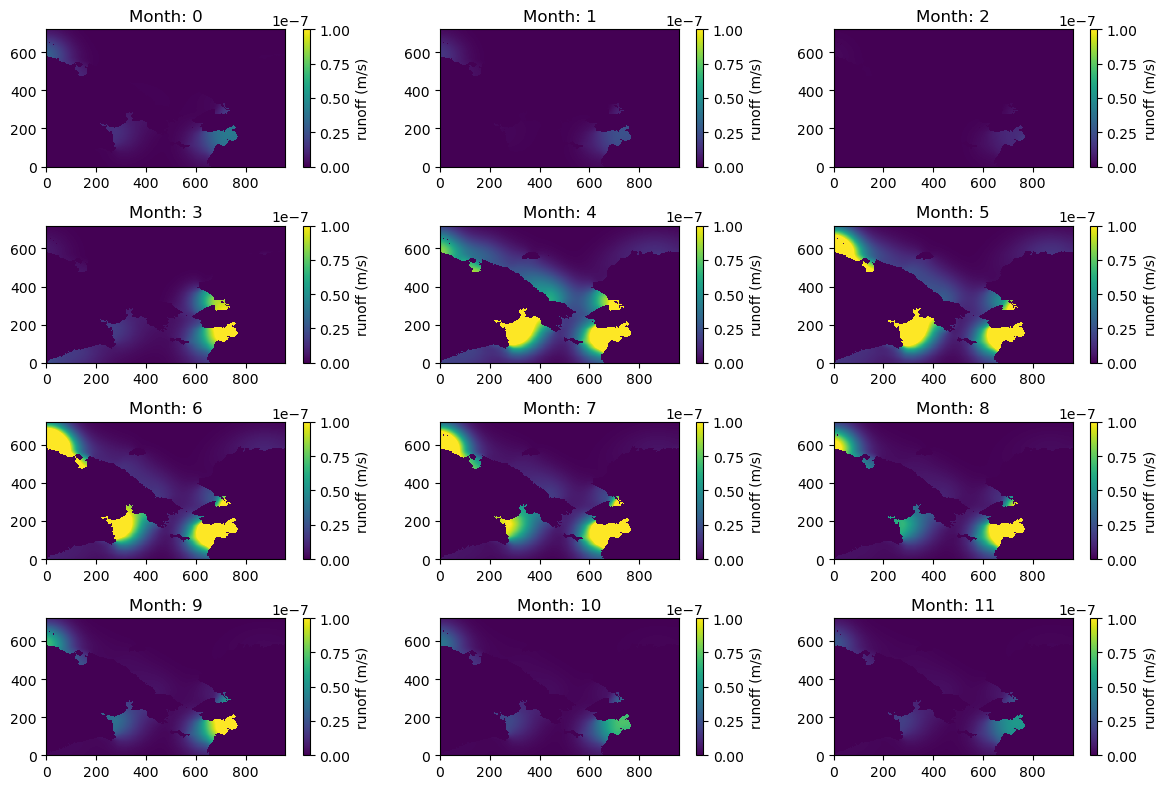

In [147]:
fig = plt.figure(figsize=(12,8))

variable_name = 'runoff'

plot_counter = 1
for month in range(12):
    init_grid = runoff_grid[month, :, :]
    
    plt.subplot(4,3,plot_counter)
    C = plt.pcolormesh(init_grid, 
                       vmin=meta_dict[variable_name][0],
                       vmax=meta_dict[variable_name][1],
                       cmap=meta_dict[variable_name][2])
    plt.colorbar(C, label=variable_name+' ('+meta_dict[variable_name][3]+')',fraction=0.26)
    plt.title('Month: '+str(month))

    plot_counter+=1

plt.tight_layout()

plt.show()

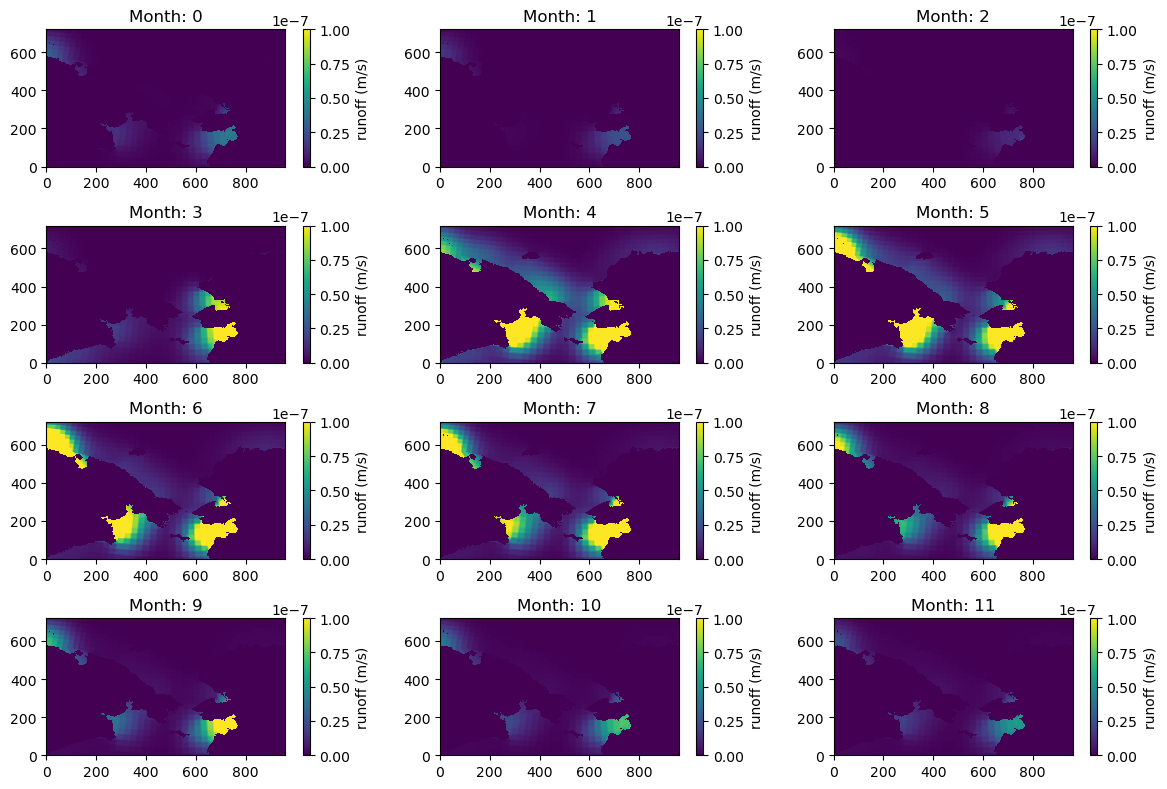

In [148]:
fig = plt.figure(figsize=(12,8))

variable_name = 'runoff'

plot_counter = 1
for month in range(12):
    init_grid = interpolated_grid[month, :, :]
    
    plt.subplot(4,3,plot_counter)
    C = plt.pcolormesh(init_grid, 
                       vmin=meta_dict[variable_name][0],
                       vmax=meta_dict[variable_name][1],
                       cmap=meta_dict[variable_name][2])
    plt.colorbar(C, label=variable_name+' ('+meta_dict[variable_name][3]+')',fraction=0.26)
    plt.title('Month: '+str(month))

    plot_counter+=1

plt.tight_layout()

plt.show()